In [81]:
import numpy as np
from surmof_cavity import ag_surmof_cavity_trref as transmission
import matplotlib.pyplot as plt
import matplotlib as mpl
from functools import partial
import contourint
import functools
from tqdm import tqdm

In [82]:
material_poles = np.array([448.79110491874115, 438.2930673770547, 412.93727009075883])/300*2*np.pi

damping = np.array([6.2, 6.0, 5.3])
gamma_half = damping*np.pi/300

material_poles = np.sqrt(material_poles**2-gamma_half**2)-1j*gamma_half

In [83]:
material_poles

array([9.39923468-0.06492625j, 9.1793735 -0.06283185j,
       8.64835987-0.05550147j])

In [84]:
pad_r = 0.02
pad_i = 0.002j
radius_r = [0.15, 0.15, 0.4, 0.9, 12]
radius_i = [0.05, 0.05, 0.1, 0.2, 5]
radius = np.array(radius_r) + 1j*np.array(radius_i)
punchout = 0.43
overlap = np.array([0.38, 0.38, 0.38, 0.5, 0.38])
num_recursions = 15#15#3
pad = -np.array([0.03, 0.07, 0.07, 0, 0])
inner_pad = -0.01

integration_centers = np.append(material_poles[:], [np.mean(material_poles[:-1]), np.mean(material_poles)])

centers = np.concatenate([ integration_centers + pad*((punchout+overlap)**i) for i in range(num_recursions) ])
inner_centers = np.concatenate([ integration_centers + inner_pad*((punchout+overlap)**i) for i in range(num_recursions) ])

num_points = [512]*len(integration_centers)*num_recursions
radii = []
for i in range(num_recursions):
    radii += list(radius*((punchout+overlap)**i))

In [85]:
(0.43+0.38)**(15/50)-0.43

0.5087403933595693

In [86]:
contours= [
    contourint.Stack(contours=[
        contourint.Ellipse(center=inner_center, radius=np.conj(radius)*punchout, num_points=nump),
        contourint.Ellipse(center=center, radius=radius, num_points=nump)
    ]) for 
    center, inner_center, radius, nump in zip(centers, inner_centers, radii, num_points)
]

In [87]:
ts = 0.025*(np.arange(50)+2)#[-4:]
all_poles = []
all_residues = []
npoles = 3
max_num_poles = 7

for thickness in tqdm(ts):
    t_poles = []
    t_residues = []
    for contour in contours:
        #functools.lru_cache(maxsize=None)()
        f = partial(transmission, thickness=thickness, npoles=npoles)
        try:
            poles, residues = contourint.locate_poles(contour, f, M=max_num_poles, cutoff=1e-12)
        except ValueError:
            poles = residues = np.array([])
        num_found = len(poles)
        missing = (max_num_poles-num_found)

        poles = np.concatenate([poles, [np.nan]*missing])
        residues = np.concatenate([residues, [np.nan]*missing])
        
        t_poles.append(poles)
        t_residues.append(residues)
    all_poles.append(t_poles)
    all_residues.append(t_residues)

  0%|          | 0/50 [00:00<?, ?it/s]

[ 0.12049006+0.12998822j -0.12049006-0.12998822j]
[ 0.07440895+0.07004653j -0.07440895-0.07004653j]
[ 0.04542672+0.03720363j -0.04542672-0.03720363j]
[ 0.02742027+0.01939884j -0.02742027-0.01939884j]
[ 0.0163586+0.0098694j -0.0163586-0.0098694j]
[ 0.00963649+0.00484979j -0.00963649-0.00484979j]
[ 0.00559553+0.00225975j -0.00559553-0.00225975j]
[ 0.00319365+0.00096034j -0.00319365-0.00096034j]
[ 0.00178353+0.00033448j -0.00178353-0.00033448j]
[ 0.00096729+5.20157682e-05j -0.00096729-5.20157755e-05j]
[ 0.0005028-6.09839008e-05j -0.0005028+6.09839062e-05j]
[ 0.00024415-9.43359728e-05j -0.00024415+9.43359046e-05j]
[ 0.00010427-9.31975772e-05j -0.00010427+9.31975737e-05j]
[ 3.17804763e-05-7.94187252e-05j -3.17813829e-05+7.94180669e-05j]
[ 0.07440895+0.07004653j -0.07440895-0.07004653j]
[ 0.04542672+0.03720363j -0.04542672-0.03720363j]
[ 0.02742027+0.01939884j -0.02742027-0.01939884j]
[ 0.0163586+0.0098694j -0.0163586-0.0098694j]
[ 0.00963649+0.00484979j -0.00963649-0.00484979j]
[ 0.00559553

  2%|▏         | 1/50 [00:11<09:25, 11.54s/it]

[5.64411188e-03+4.59759740e-03j 6.45957462e+00+8.07414245e+00j]
[ 2.95352845e-03+2.19793684e-03j -1.82080890e+01-2.38552619e+01j]
[1.54023749e-03+1.04422567e-03j 4.82791845e+01+6.74216219e+01j]
[ 8.00541156e-04+4.92578856e-04j -1.32528590e+02-1.95056492e+02j]
[4.14727508e-04+2.30441219e-04j 3.54160727e+02+5.55325579e+02j]
[ 2.14163385e-04+1.06757811e-04j -9.58515525e+02-1.59267342e+03j]
[1.10239565e-04+4.88801477e-05j 2.55988861e+03+4.53884313e+03j]
[ 5.65630788e-05+2.20585748e-05j -6.85880492e+03-1.29590876e+04j]
[2.89275428e-05+9.77356865e-06j 1.82297510e+04+3.68927143e+04j]
[ 1.47447728e-05+4.22715725e-06j -4.83922953e+04-1.05028703e+05j]
[7.48965356e-06+1.76833430e-06j 1.27638019e+05+2.98509421e+05j]
[ 3.79064841e-06+7.04108445e-07j -3.35351481e+05-8.47897550e+05j]
[ 0.17310469+0.19230737j -0.17310469-0.19230737j]
[ 0.08871489+0.07492733j -0.08871489-0.07492733j]
[ 0.04333537+0.02687045j -0.04333537-0.02687045j]
[ 0.02003898+0.00814702j -0.02003898-0.00814702j]
[ 0.00858499+0.00141

  4%|▍         | 2/50 [00:23<09:17, 11.61s/it]

...

[-1.66885970e+00-1.01047703e+00j -7.87428974e+04-2.84516614e+04j]
[-2.52604300e+00-1.48104168e+00j  3.95211473e+05+2.12012373e+05j]
[-0.01518747-0.0128367j   0.28358484+0.21846116j]
[-0.0233065 -0.01915874j -0.18612104+0.0588024j ]
[-0.0359645 -0.02873103j  2.95773757+2.14587741j]
[-0.05574098-0.04319179j -2.96865955-0.155589j  ]
[-0.0859893  -0.0646466j 31.01778477+21.1715334j]
[ -0.13228312-0.09649086j -41.27226076-8.76489778j]
[-2.03073594e-01-1.43685196e-01j  3.27098999e+02+2.10001156e+02j]
[-3.10936151e-01  -0.21337187j -5.33116037e+02-156.68464839j]
[-4.74942338e-01-3.16016675e-01j  3.46804948e+03+2.09511033e+03j]
[-7.23705115e-01-4.66787498e-01j -6.57959791e+03-2.22339699e+03j]
[-1.10020890e+00-6.87677813e-01j  3.69466303e+04+2.10210134e+04j]
[-1.66885970e+00-1.01047703e+00j -7.87428974e+04-2.84516614e+04j]
[-2.52604300e+00-1.48104168e+00j  3.95211473e+05+2.12012373e+05j]
[-3.81578694e+00-2.16536874e+00j -9.21877358e+05-3.43250474e+05j]
[ 0.03177132+0.03031614j -0.00049248-0.000

 98%|█████████▊| 49/50 [09:22<00:11, 11.41s/it]

[-2.62543364e+02-1.43717946e+02j  2.57384608e+08+2.67150573e+08j]
[-0.00973056-0.00852232j -0.01399077+0.00854052j]
[-0.01512507-0.01282398j  0.28551814+0.21680886j]
[-0.02307653-0.01903701j -0.26873477-0.00410177j]
[-0.03543556-0.02840533j  3.0546498 +2.17415182j]
[-0.05455509-0.04242822j -4.09110521-0.94434939j]
[-0.08358905 -0.06309517j 32.99366303+22.01483195j]
[ -0.12774171 -0.09358363j -56.05359248-18.44556032j]
[-1.94799177e-01-1.38478423e-01j  3.59430307e+02+2.25120311e+02j]
[-2.96297754e-01-2.04356147e-01j -7.23592721e+02-2.73776166e+02j]
[-4.49616059e-01-3.00793218e-01j  3.94454238e+03+2.32371006e+03j]
[-6.80663711e-01-4.41588241e-01j -8.99386125e+03-3.62386204e+03j]
[-1.02812275e+00-6.46634850e-01j  4.35471592e+04+2.41858252e+04j]
[-1.54959612e+00-9.44525198e-01j -1.08934650e+05-4.50447025e+04j]
[-2.33076488e+00-1.37627530e+00j  4.82950334e+05+2.53498877e+05j]
[-0.01512507-0.01282398j  0.28551814+0.21680886j]
[-0.02307653-0.01903701j -0.26873477-0.00410177j]
[-0.03543556-0.0

100%|██████████| 50/50 [09:34<00:00, 11.48s/it]

[-0.00976498-0.00857292j -0.01952172+0.003922j  ]
[-0.01502367-0.01278604j  0.28937538+0.21673583j]
[-0.02279754-0.01888299j -0.35212712-0.06682186j]
[-0.03482647-0.02802802j  3.18760685+2.22921274j]
[-0.05325729-0.04159583j -5.27592471-1.76454957j]
[-0.08105467 -0.06146551j 35.58601753+23.28169082j]
[ -0.1230617 -0.09060254j -72.3592743-28.96767628j]
[-1.86435569e-01-1.33238068e-01j  4.01676640e+02+2.46622323e+02j]
[-2.81737486e-01-1.95419744e-01j -9.42884266e+02-4.06874413e+02j]
[-4.24772380e-01-2.85899572e-01j  4.57324513e+03+2.64493703e+03j]
[-6.38959543e-01-4.17217355e-01j -1.18899006e+04-5.28778764e+03j]
[-9.59051078e-01-6.07351273e-01j  5.23995498e+04+2.86536705e+04j]
[-1.43648624e+00-8.81998679e-01j -1.46606984e+05-6.56286075e+04j]
[-2.14732325e+00-1.27782422e+00j  6.03016232e+05+3.12840584e+05j]
[-0.01502367-0.01278604j  0.28937538+0.21673583j]
[-0.02279754-0.01888299j -0.35212712-0.06682186j]
[-0.03482647-0.02802802j  3.18760685+2.22921274j]
[-0.05325729-0.04159583j -5.275924

In [88]:
wfreqs = []

wfreqrs = [pole.real - np.logspace(-6, -0.8, 800) for pole in material_poles] 
wfreqr = np.concatenate(wfreqrs)

wfreqi = np.linspace(-0.05, -0.07, 200)

wfreqr = np.concatenate([wfreqr ,np.linspace(8.2, 9.5, 200)])
wfreqr = np.sort(wfreqr)

wfreqi = np.concatenate([wfreqi, np.linspace(-1, 0.2, 200)])
wfreqi = np.sort(wfreqi)

Wfreqr, Wfreqi = np.meshgrid(wfreqr, wfreqi, indexing='ij')
Wfreq = Wfreqr + 1j*Wfreqi

In [89]:
F = f(Wfreq)

In [90]:
tolerances = np.sqrt(np.abs(np.array(radii))) * 1e-3
num_centers = len(integration_centers)
num_shells = len(radii)//num_centers
search_shells = 4
min_hits = 2
filtered_all_poles = []
for t_poles in all_poles: # poles of a given thickness
    filtered_t_poles = []
    f_t_residues = [] # TODO
    for i_center, center in enumerate(integration_centers):
        c_poles = t_poles[i_center::num_centers]
        for (i, outer), tol in zip(enumerate(c_poles), tolerances):
            for reference_pole in outer: # one specific pole
                hits = 0
                for idx_inner_shell in range(min(num_shells-i, search_shells)):
                    dist = np.abs(reference_pole - c_poles[i + idx_inner_shell])
                    hits += np.any(dist<tol)
                if hits>min_hits:
                    filtered_t_poles.append(reference_pole)
                    f_t_residues = []
    filtered_all_poles.append(filtered_t_poles)

/tmp/ipykernel_3147133/3918967910.py:16: RuntimeWarning: invalid value encountered in subtract
  dist = np.abs(reference_pole - c_poles[i + idx_inner_shell])


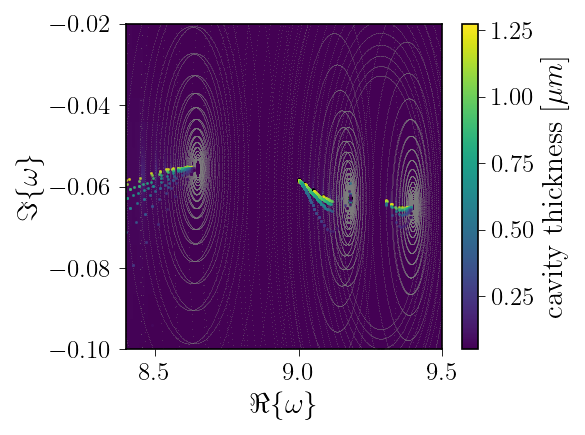

In [91]:
cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min(ts), vmax=max(ts))
colors = cmap(norm(ts))

plt.pcolormesh(Wfreqr, Wfreqi, np.abs(F).astype(float), alpha=1, rasterized=True, vmax=1e1)
xlim, ylim = plt.xlim(), plt.ylim()

for contour in contours:
    plt.scatter(contour.points.real, contour.points.imag, s=0.1, alpha = 0.4, color="gray")

first = True
for color, t_poles in list(zip(colors, filtered_all_poles))[::-1]:
    poles = np.array(t_poles).flatten()
    s = 1.5
    if first:
        first=False
        s=3
        color="k"
    plt.scatter(poles.real, poles.imag, color=color, s=s, alpha = 0.9)

# for color, t_poles in list(zip(colors, all_poles))[::-1]:
#     poles = np.array(t_poles).flatten()
#     s = 1.5
#     plt.scatter(poles.real, poles.imag, color=color, s=s, alpha = 0.3)

plt.colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm), ax=plt.gca(), label="cavity thickness [$\mu m$]")

plt.xlabel("$\Re\{\omega\}$")
plt.ylabel("$\Im\{\omega\}$")

plt.xlim(xlim)
plt.ylim(ylim)

# plt.savefig("out/poles_overview.pdf", dpi=300)


plt.xlim(8.4, 9.5)
plt.ylim(-0.1, -0.02)
plt.savefig("out/poles_zoom.pdf", dpi=300)

In [92]:
results = {'filtered_poles': filtered_all_poles, 'thicknesses': ts}

In [93]:
np.save("out/3poles/ag_surmof.npy", results)

In [94]:
all_results = {'all_poles': all_poles, "all_residues": all_residues}

In [95]:
np.save("out/3poles/all_ag_surmof.npy", all_results)